> **Optional advanced material.** This notebook is part of the *advanced,
> optional path* of this series — interpretability research aimed at data
> scientists and ML practitioners who want to look inside a real language
> model's internals. It goes well beyond what's needed for the main
> oilfield lessons and assumes comfort with Python, PyTorch tensors, and
> general deep-learning concepts.
>
> **You do not need this notebook** to get practical value from the main
> path — see `../notebooks/01_how_a_real_llm_predicts_the_next_token.ipynb`
> and `../notebooks/02_temperature_sampling_and_decoding_strategies.ipynb`,
> or the project [README](../README.md), for that.


# Looking Inside the Model: Embeddings and Attention (With Real Caveats)

**Notebook 1 of the series.** The main path's notebooks 1 and 2 treated the transformer as a
box that turns a prompt into a probability distribution, and then a decoding
strategy into generated text. This notebook opens that box slightly further
and inspects two things a real, loaded model exposes:

1. **Token embeddings** — the vectors every token ID is converted into
   before any transformer processing happens.
2. **Attention weights** — real, computed numbers from inside the
   transformer showing how much each position's information contributed to
   another position's updated representation, at a given layer and head.

**A caution stated up front, because it matters more here than anywhere
else in this series:** everything you'll see below is a real number read
directly out of the loaded model — nothing is invented. But neither
embedding similarity nor attention weight is, by itself, a complete
explanation of *why* the model produced a particular prediction. Published
interpretability research has repeatedly found cases where attention
weights don't align with what more rigorous methods identify as causally
important. This notebook treats both tools as **descriptive and
exploratory**, not as proof of causation — and says so explicitly wherever
that distinction matters.

Still out of scope: gradient-based attribution, activation patching, causal
tracing, probing classifiers, and fine-tuning. Those are genuine
interpretability techniques, but they need more machinery than a single
forward pass and are left for a possible future notebook.

## Learning objectives

1. What is a token embedding vector, and what does "closeness" between two
   embeddings mean — and not mean?
2. What do real embedding similarities look like for oilfield terms, and
   why do they sometimes track spelling rather than meaning?
3. What is attention, mechanically, inside a transformer layer?
4. What do real attention weights look like for an oilfield sentence, and
   how do they differ across layers?
5. Why is "the model attended to X, therefore X explains the prediction" an
   overclaim — and what, more modestly, can we actually say?


## 1. What problem are we investigating?

The full pipeline from the main path's notebooks 1–2 looked like this:

```
prompt -> tokenizer -> token IDs -> transformer -> logits -> softmax -> probabilities -> decoding -> next token
```

Everything between "token IDs" and "logits" was a black box we didn't open.
Inside that box, two things happen that we can inspect from a
single forward pass:

```
token IDs -> [ embedding lookup ] -> [ N transformer layers, each computing attention + an MLP ] -> logits
```

This notebook inspects the embedding lookup (Section 4) and the attention
weights computed inside the transformer layers (Sections 7–10) — using the
same real oilfield prompts as before, and the same insistence that every
number shown came directly from the loaded model.


## Installation (run once)

Same dependencies as the main path's notebooks 1 and 2. If you already set those up, skip
this cell.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

This notebook loads the model a little differently from the main path's notebooks 1–2, for
two concrete, tested reasons:

1. **`attn_implementation="eager"` is required.** The fast default
   attention kernel (`sdpa`) does not compute or return attention weights at
   all — requesting `output_attentions=True` with it silently produces an
   *empty* result (verified while building this notebook: `out.attentions`
   comes back as `()`, not real data). Only the slower, literal "eager"
   implementation materializes the actual attention matrices we want to
   inspect.
2. **`float32` is required, not `float16`.** On this machine's Apple
   Silicon (MPS) backend, computing eager attention in float16 produced
   `NaN` attention weights — a real, reproducible numerical issue observed
   while building this notebook, not a hypothetical one. Float32 does not
   exhibit it, on MPS, CUDA, or CPU. Since eager attention already forfeits
   the speed advantage of the fast kernel, and this model is small enough
   to run comfortably in float32, we use float32 throughout this notebook.


In [2]:
import random
import platform
import sys

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
PRIMARY_MODEL_REVISION = "989aa7980e4cf806f80c7fef2b1adb7bc71aa306"  # pinned for reproducibility
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load
FALLBACK_MODEL_REVISION = "7ae557604adf67be50417f59c2c2f167def9a775"  # pinned for reproducibility

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# float32 throughout this notebook: eager attention needs it for numerical
# stability (see explanation above), and we've already given up the speed
# benefit of float16 by requiring eager attention in the first place.
DTYPE = torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float32


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model (with eager attention, for real attention weights) and its tokenizer.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    candidates = [(model_name, PRIMARY_MODEL_REVISION), (FALLBACK_MODEL_NAME, FALLBACK_MODEL_REVISION)]
    for i, (name, revision) in enumerate(candidates):
        try:
            tok = AutoTokenizer.from_pretrained(name, revision=revision)
            mdl = AutoModelForCausalLM.from_pretrained(name, revision=revision, dtype=DTYPE, attn_implementation="eager", use_safetensors=True)
            mdl.to(DEVICE)
            mdl.eval()
            return tok, mdl, name
        except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
            if i == len(candidates) - 1:
                raise
            print(f"Could not load '{name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")


tokenizer, model, MODEL_NAME = load_model()
NUM_LAYERS = model.config.num_hidden_layers
NUM_HEADS = model.config.num_attention_heads
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")
print(f"Transformer layers: {NUM_LAYERS}, attention heads per layer: {NUM_HEADS}")
print(f"Attention implementation in use: {model.config._attn_implementation}")
assert model.config._attn_implementation == "eager", "Eager attention is required for real output_attentions."



Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens
Transformer layers: 28, attention heads per layer: 12
Attention implementation in use: eager


## 3. Reference prompt

Same primary sentence as the main path's notebooks 1 and 2, so results stay comparable
across the series.


In [4]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

encoded = tokenizer(PROMPT, return_tensors="pt")
input_ids = encoded["input_ids"][0]
decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]

token_table = pd.DataFrame({
    "position": range(len(input_ids)),
    "token_id": input_ids.tolist(),
    "decoded_token_repr": [repr(t) for t in decoded_tokens],
})
print(repr(PROMPT))
token_table


'The crew pulled out of hole with the worn PDC bit and prepared to run a new'


,position,token_id,decoded_token_repr
0,0,785,'The'
1,1,13627,' crew'
2,2,13238,' pulled'
3,3,700,' out'
4,4,315,' of'
5,5,14178,' hole'
6,6,448,' with'
7,7,279,' the'
8,8,23704,' worn'
9,9,393,' P'


## 4. What is a token embedding?

Before any transformer layer runs, every token ID is looked up in an
**embedding matrix**: one real-valued vector per vocabulary entry. This
lookup is literally the first thing that happens to your tokenized prompt.

We read this matrix directly from the loaded model — it is not derived or
approximated.


In [5]:
embedding_matrix = model.get_input_embeddings().weight.detach().to("cpu", dtype=torch.float32)
print(f"Embedding matrix shape: {tuple(embedding_matrix.shape)}  (vocab_size x hidden_size)")

embedding_matrix_norm = torch.nn.functional.normalize(embedding_matrix, dim=-1)


def first_token_id(word_with_space: str) -> int:
    '''Return the token ID for the first token produced when encoding a word (with its leading space).'''
    return tokenizer.encode(word_with_space, add_special_tokens=False)[0]


def get_token_embedding(word_with_space: str) -> torch.Tensor:
    '''Return the raw embedding vector for the first token of `word_with_space`, and report what was actually embedded.'''
    tid = first_token_id(word_with_space)
    actual_token = tokenizer.decode([tid])
    if actual_token != word_with_space:
        print(f"Note: {word_with_space!r} tokenizes to more than one token; "
              f"embedding shown is for its first token only, {actual_token!r}.")
    return embedding_matrix[tid]


sample_vector = get_token_embedding(" bit")
print(f"\nEmbedding vector for ' bit': shape {tuple(sample_vector.shape)}, first 8 values: {sample_vector[:8].tolist()}")


Embedding matrix shape: (151936, 1536)  (vocab_size x hidden_size)



Embedding vector for ' bit': shape (1536,), first 8 values: [-0.0302734375, 0.0576171875, -0.0004444122314453125, -0.022705078125, -0.0224609375, 0.0206298828125, -0.0269775390625, 0.0810546875]


### Similarity between oilfield term embeddings

We measure similarity with **cosine similarity** (the cosine of the angle
between two vectors: 1.0 means identical direction, 0 means unrelated, -1
means opposite). We deliberately picked the terms below because the
tokenizer represents each of them as a single token — so each similarity
score reflects one whole term's embedding, with no multi-token averaging or
approximation involved.


In [6]:
def cosine_similarity(vec_a: torch.Tensor, vec_b: torch.Tensor) -> float:
    return float(torch.nn.functional.cosine_similarity(vec_a.unsqueeze(0), vec_b.unsqueeze(0)).item())


single_token_terms = [
    " bit", " pipe", " hole", " well", " string", " liner", " casing",
    " cement", " fishing", " logging", " drilling", " completion", " tubing", " ESP",
]

term_vectors = {term: get_token_embedding(term) for term in single_token_terms}

n = len(single_token_terms)
similarity_matrix = np.zeros((n, n))
for i, term_a in enumerate(single_token_terms):
    for j, term_b in enumerate(single_token_terms):
        similarity_matrix[i, j] = cosine_similarity(term_vectors[term_a], term_vectors[term_b])

similarity_df = pd.DataFrame(similarity_matrix, index=single_token_terms, columns=single_token_terms).round(2)
similarity_df


,bit,pipe,hole,well,string,liner,casing,cement,fishing,logging,drilling,completion,tubing,ESP
bit,1.00,0.01,0.06,0.05,0.03,0.01,0.02,0.00,-0.03,0.01,0.02,0.02,-0.04,-0.02
pipe,0.01,1.00,0.11,0.02,0.05,0.10,0.10,0.03,-0.00,0.05,0.09,0.03,0.35,0.04
hole,0.06,0.11,1.00,0.03,0.02,0.07,0.10,0.05,0.05,0.03,0.23,0.06,0.08,0.02
well,0.05,0.02,0.03,1.00,0.03,0.00,0.05,-0.00,-0.00,0.03,0.03,0.01,0.02,-0.01
string,0.03,0.05,0.02,0.03,1.00,-0.01,0.01,-0.02,0.04,0.05,0.01,-0.01,0.05,-0.00
liner,0.01,0.10,0.07,0.00,-0.01,1.00,0.11,0.06,0.10,0.06,0.07,0.03,0.12,0.04
casing,0.02,0.10,0.10,0.05,0.01,0.11,1.00,0.10,0.11,0.10,0.17,0.08,0.22,0.10
cement,0.00,0.03,0.05,-0.00,-0.02,0.06,0.10,1.00,0.08,0.08,0.12,0.07,0.07,0.05
fishing,-0.03,-0.00,0.05,-0.00,0.04,0.10,0.11,0.08,1.00,0.16,0.19,0.04,0.12,0.06
logging,0.01,0.05,0.03,0.03,0.05,0.06,0.10,0.08,0.16,1.00,0.14,0.06,0.11,0.03


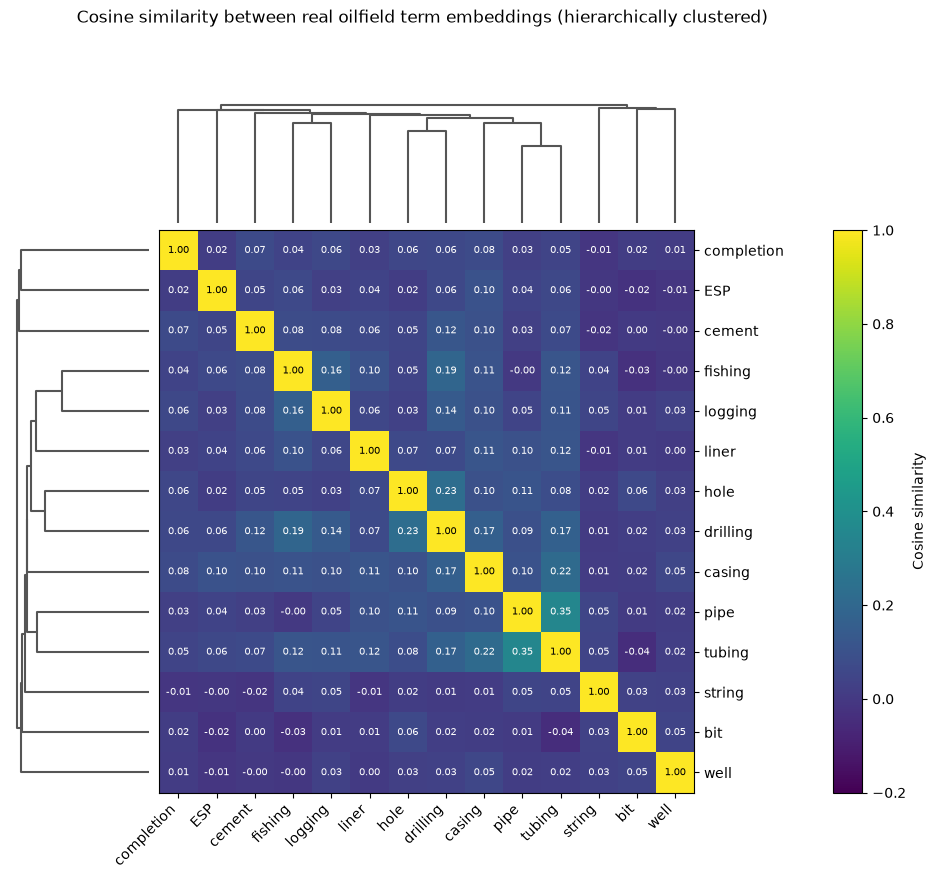

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Real hierarchical clustering: group terms by their actual embedding
# distance (1 - cosine similarity), not by a hand-picked order or an
# assumed oilfield taxonomy.
term_matrix = torch.stack([term_vectors[t] for t in single_token_terms]).numpy()
distances = pdist(term_matrix, metric="cosine")
linkage_matrix = linkage(distances, method="average")

labels = [t.strip() for t in single_token_terms]

fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 4, width_ratios=(1.3, 5, 1.1, 0.28), height_ratios=(1.1, 5),
                       wspace=0.05, hspace=0.02)

ax_top = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[1, 0])
ax_heat = fig.add_subplot(gs[1, 1])
ax_cbar = fig.add_subplot(gs[1, 3])

dendro_top = dendrogram(linkage_matrix, ax=ax_top, no_labels=True,
                         color_threshold=0, above_threshold_color="#555555")
ax_top.axis("off")

dendrogram(linkage_matrix, ax=ax_left, orientation="left", no_labels=True,
           color_threshold=0, above_threshold_color="#555555")
ax_left.axis("off")

# Both dendrograms come from the same linkage_matrix, so they always agree
# on leaf order -- we just read it once, from whichever call we already made.
order = dendro_top["leaves"]
ordered_labels = [labels[i] for i in order]
ordered_matrix = similarity_matrix[np.ix_(order, order)]

im = ax_heat.imshow(ordered_matrix, cmap="viridis", vmin=-0.2, vmax=1.0, aspect="auto")
ax_heat.set_xticks(range(n))
ax_heat.set_xticklabels(ordered_labels, rotation=45, ha="right")
ax_heat.set_yticks(range(n))
ax_heat.set_yticklabels(ordered_labels)
ax_heat.yaxis.tick_right()

for i in range(n):
    for j in range(n):
        val = ordered_matrix[i, j]
        color = "white" if val < 0.4 else "black"
        ax_heat.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=7.5)

fig.colorbar(im, cax=ax_cbar, label="Cosine similarity")
fig.suptitle("Cosine similarity between real oilfield term embeddings (hierarchically clustered)", y=0.98, fontsize=12)
plt.show()


**Interpretation:** read the actual values in the table and chart
above rather than assuming which terms "should" be similar. Raw input
embeddings capture whatever geometric structure the model's training
produced — which is not always a clean map of human-recognizable oilfield
categories. The dendrograms above are the model's own hierarchical
grouping of these terms, computed directly from embedding distance — not
a category scheme we imposed. Read honestly, it does not resolve into
clean, human-recognizable oilfield groups: similarities are almost
uniformly low (mostly under 0.2), and the tightest pairs it does find
("pipe"/"tubing" at 0.35, "hole"/"drilling" at 0.23) are at best loosely
thematic, not a full "tubulars" or "drilling operations" cluster. That is
a real, honest finding about this model's raw input embeddings, not a
shortcoming of the clustering method.


### Nearest neighbors in embedding space

Instead of a curated list, let's ask the model directly: across its *entire*
vocabulary, which tokens have the highest cosine similarity to a given
oilfield term's embedding? For terms that tokenize into more than one piece
(like "packer" or "POOH"), we honestly compute neighbors of the first
sub-token only, and say so.


In [8]:
def nearest_neighbors(word_with_space: str, top_n: int = 8) -> pd.DataFrame:
    '''Return the top_n vocabulary tokens with the highest cosine similarity to word_with_space's (first-subtoken) embedding.'''
    tid = first_token_id(word_with_space)
    actual_token = tokenizer.decode([tid])
    query_vec = embedding_matrix_norm[tid]
    similarities = embedding_matrix_norm @ query_vec
    top_scores, top_ids = torch.topk(similarities, top_n)
    return pd.DataFrame({
        "queried_term": word_with_space,
        "actual_embedded_token": repr(actual_token),
        "neighbor_token": [repr(tokenizer.decode([i])) for i in top_ids.tolist()],
        "cosine_similarity": top_scores.tolist(),
    })


for term in [" bit", " packer", " POOH"]:
    display(nearest_neighbors(term))


,queried_term,actual_embedded_token,neighbor_token,cosine_similarity
0,bit,' bit',' bit',1.000001
1,bit,' bit',' Bit',0.795346
2,bit,' bit','bit',0.780728
3,bit,' bit','Bit',0.767266
4,bit,' bit','_bit',0.757750
5,bit,' bit','-bit',0.746984
6,bit,' bit','\tbit',0.722856
7,bit,' bit',' bits',0.697879


,queried_term,actual_embedded_token,neighbor_token,cosine_similarity
0,packer,' pack',' pack',1.000000
1,packer,' pack',' Pack',0.785036
2,packer,' pack',' packs',0.777507
3,packer,' pack','pack',0.755715
4,packer,' pack','Pack',0.735343
5,packer,' pack','-pack',0.718380
6,packer,' pack','_pack',0.690903
7,packer,' pack','(pack',0.687838


,queried_term,actual_embedded_token,neighbor_token,cosine_similarity
0,POOH,' PO',' PO',1.000000
1,POOH,' PO','PO',0.752004
2,POOH,' PO','_PO',0.629660
3,POOH,' PO',' Po',0.626741
4,POOH,' PO','Po',0.600796
5,POOH,' PO',' po',0.586159
6,POOH,' PO','_po',0.569353
7,POOH,' PO','po',0.566821


**Interpretation:** for these queries, the nearest neighbors are
dominated by spelling and capitalization variants (`' bit'` / `'Bit'` /
`'-bit'`) or sub-token fragments (`' packer'`'s first piece, `' pack'`,
neighboring `' Pack'` / `' packs'`) — not by oilfield-meaning relationships
like "bit" being close to "PDC" or "reamer". That is a real, honest finding
about this model's *raw input embeddings*, and it teaches something
important: an input embedding mostly encodes a token's surface form.
Genuine contextual meaning — the kind that would let a model relate "bit" to
drilling — emerges only after the transformer layers process a token
*together with the tokens around it*, which is exactly what attention,
inspected next, starts to do.


## 5. What is attention, mechanically?

Inside each transformer layer, every token position produces three vectors
derived from its current representation: a **query** (Q), a **key** (K), and
a **value** (V). Attention computes, for each position, a weighted average
of every position's value vector — where the weights come from comparing
that position's query against every position's key:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

- $QK^T$ compares every query against every key (how well they "match")
- dividing by $\sqrt{d_k}$ (the key dimension) keeps the scores at a stable
  scale
- softmax turns those scores into a distribution over positions, for each
  query position — the numbers we'll extract and inspect below
- multiplying by $V$ produces the actual weighted mix of value vectors

Real models run this in parallel across many **heads** (each with its own Q/K/V
projections) and many **layers**, then combine the results.

**An intuition for why there are multiple heads.** Picture the same real-time
drilling report handed, at the same moment, to several different people on a
well site: a drilling engineer, a drilling superintendent, and a logistics
coordinator. All three read the identical text, but each is trained to weigh
different parts of it — the drilling engineer's eye goes straight to torque,
ROP, and bit condition; the superintendent's to overall job status and what
happens next; the logistics coordinator's to what equipment needs to move
where. Each produces their own read of the same report, and those separate
reads get pooled into one shared picture that informs the next decision.

A transformer head works the same way, mechanically, not thematically: every
head runs the identical Q/K/V computation above on the identical input, but
each head has its **own**, separately learned Q, K, and V projections — so each
head can end up weighting the *same* context differently, the way each
specialist weights the same report differently. The model then combines every
head's output (via a learned output projection) before passing it on to the
next layer.

```
same input, read in parallel by every head in the layer
   |
   +-- head 1 (own Q, K, V) -> its own weighting of the same context
   +-- head 2 (own Q, K, V) -> its own weighting of the same context
   +-- ...                  -> (12 heads in this model)
   |
   v
combined via a learned output projection, passed to the next layer
```

**Where the analogy has to stop.** Real specialists have job titles and known
responsibilities; real attention heads don't. A head's "specialty," if it has
one recognizable at all, is whatever pattern happened to fall out of training —
nobody assigns it, and it can only be found by inspecting the head directly,
not assumed from a label. Notebook 5 does exactly that later in this series: it
isolates one real head and checks, honestly, whether its attention pattern
tells a plausible story — treating agreement between that story and a causal
test as evidence, not proof.

This notebook inspects only the *softmax attention weights themselves* — the
part shown in the formula above — not the underlying Q, K, or V vectors.


## 6. Extracting real attention weights

We run the same prompt through the model with `output_attentions=True`.
The result, `outputs.attentions`, is a tuple with one entry per transformer
layer; each entry has shape `(batch, num_heads, sequence_length,
sequence_length)` — one full attention matrix per head.


In [9]:
encoded = encoded.to(DEVICE)

with torch.no_grad():
    outputs = model(**encoded, output_attentions=True)

assert outputs.attentions is not None and len(outputs.attentions) > 0, (
    "No attention weights were returned - check that attn_implementation='eager' actually took effect."
)

print(f"Number of layers with attention returned: {len(outputs.attentions)}")
print(f"Shape of one layer's attention tensor: {tuple(outputs.attentions[0].shape)}")
print("(batch, num_heads, sequence_length, sequence_length)")


Number of layers with attention returned: 28
Shape of one layer's attention tensor: (1, 12, 18, 18)
(batch, num_heads, sequence_length, sequence_length)


In [10]:
def last_token_attention(layer_index: int) -> torch.Tensor:
    '''Real attention weights for the final token position at `layer_index`, averaged over all heads.'''
    layer_attention = outputs.attentions[layer_index][0].float()  # (num_heads, seq, seq)
    averaged_over_heads = layer_attention.mean(dim=0)              # (seq, seq)
    return averaged_over_heads[-1]                                  # (seq,) - final token's row


last_layer_attention = last_token_attention(NUM_LAYERS - 1)
attention_sum = last_layer_attention.sum().item()
print(f"Sum of the final token's attention weights (last layer, averaged over heads): {attention_sum:.6f}")
assert abs(attention_sum - 1.0) < 1e-3, "Each position's attention weights (post-softmax) should sum to ~1."
print("Sanity check passed.")


Sum of the final token's attention weights (last layer, averaged over heads): 1.000000
Sanity check passed.


## 7. Visualizing attention: which tokens does the final position attend to?

A bar chart of the final token's real attention weights (last layer,
averaged across all heads) over every position in the prompt.


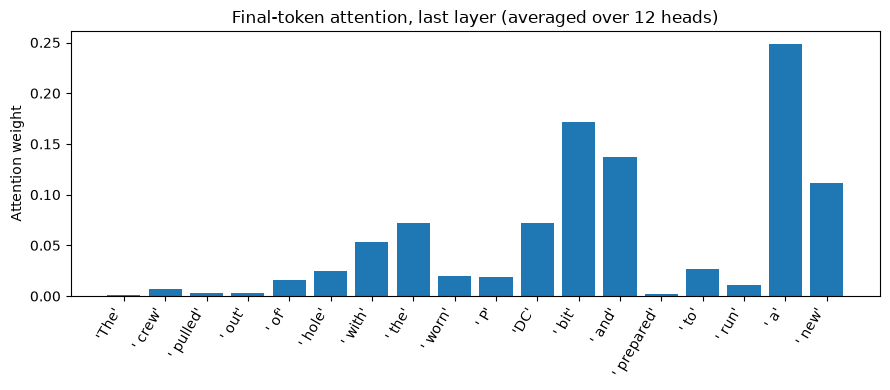

In [11]:
def plot_attention(attention_weights: torch.Tensor, labels: list, title: str):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(range(len(labels)), attention_weights.tolist())
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylabel("Attention weight")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


position_labels = [repr(t) for t in decoded_tokens]
plot_attention(last_layer_attention, position_labels, f"Final-token attention, last layer (averaged over {NUM_HEADS} heads)")


**Interpretation:** the tallest bars show which input positions this
particular layer's attention mechanism weighted most heavily when updating
the final position's representation. That is a real, precisely defined
number — not yet an explanation of the eventual predicted token (Section
9 addresses that distinction directly).


## 8. Does the attention pattern change across layers?

Let's compare the final token's attention distribution at an early layer, a
middle layer, and the last layer — three real, independently computed
distributions from the same forward pass.


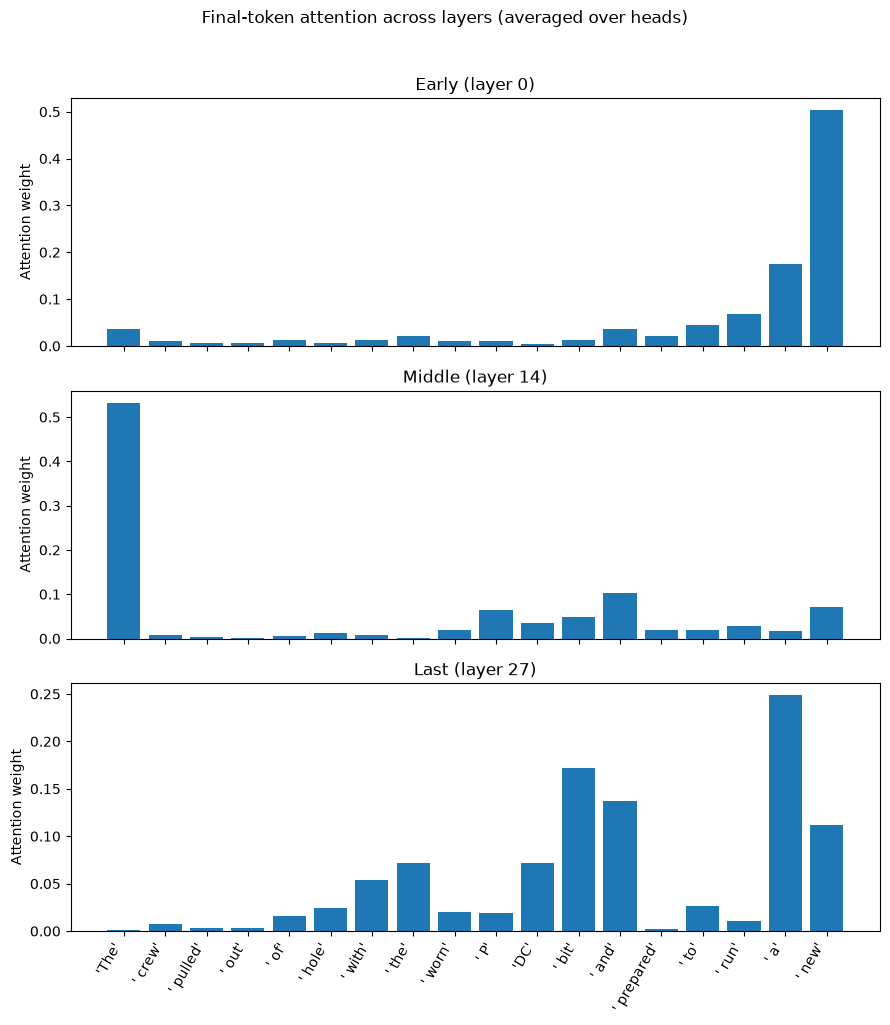

In [12]:
layer_indices = {"Early (layer 0)": 0, f"Middle (layer {NUM_LAYERS // 2})": NUM_LAYERS // 2, f"Last (layer {NUM_LAYERS - 1})": NUM_LAYERS - 1}

fig, axes = plt.subplots(len(layer_indices), 1, figsize=(9, 10), sharex=True)
for ax, (label, layer_idx) in zip(axes, layer_indices.items()):
    weights = last_token_attention(layer_idx)
    ax.bar(range(len(position_labels)), weights.tolist())
    ax.set_ylabel("Attention weight")
    ax.set_title(label)

axes[-1].set_xticks(range(len(position_labels)))
axes[-1].set_xticklabels(position_labels, rotation=60, ha="right")
fig.suptitle("Final-token attention across layers (averaged over heads)", y=1.02)
fig.tight_layout()
plt.show()


**Interpretation:** compare the shapes of these three real
distributions rather than assuming a pattern in advance (e.g. "early layers
are always positional, late layers are always semantic" is a common
simplification in the interpretability literature, but it is not
universally true, and we haven't verified it here — we're only reporting
what this specific prompt, in this specific model, actually shows).


## 9. Attention alongside the next-token prediction — not as its cause

Let's also compute the real next-token distribution from this same forward
pass, so we can look at both real measurements side by side.


In [13]:
next_token_logits = outputs.logits[0, -1, :]
next_token_probs = torch.softmax(next_token_logits, dim=-1)
top_probs, top_ids = torch.topk(next_token_probs, 5)

top_tokens_table = pd.DataFrame({
    "rank": range(1, 6),
    "decoded_token": [repr(tokenizer.decode([tid])) for tid in top_ids.tolist()],
    "probability_percent": [f"{p * 100:.2f}%" for p in top_probs.tolist()],
})
print("Top-5 next-token candidates (same forward pass as the attention weights above):")
display(top_tokens_table)

print("\nFinal-token attention weights, last layer (same forward pass):")
display(pd.DataFrame({"position_token": position_labels, "attention_weight": last_layer_attention.tolist()}))


Top-5 next-token candidates (same forward pass as the attention weights above):


,rank,decoded_token,probability_percent
0,1,' bit',33.50%
1,2,' one',27.77%
2,3,' P',7.48%
3,4,' ',2.53%
4,5,' drill',1.97%



Final-token attention weights, last layer (same forward pass):


,position_token,attention_weight
0,'The',0.001123
1,' crew',0.007101
2,' pulled',0.003385
3,' out',0.003518
4,' of',0.016107
5,' hole',0.024431
6,' with',0.053461
7,' the',0.072224
8,' worn',0.019756
9,' P',0.019183


**What we can say:** both tables above come from the exact same
forward pass over the exact same prompt. **What we cannot say:** that the
positions receiving high attention weight in the last layer *caused* the
top-ranked next token above. Attention is one intermediate computation among
many (residual connections, MLP layers, every other layer and head) that
jointly determine the final logits. A token can matter a great deal for the
final prediction while receiving low attention weight at any single layer,
and vice versa. Treat the two tables as two real, related, but separately
computed observations — not as a demonstrated cause and effect.


## 10. What attention weights can — and cannot — tell us

We can honestly say, because we computed it directly above:

- an attention weight is a real, precisely defined number: how much one
  position's value vector contributes to another position's updated
  representation, at a specific layer and head, after softmax
  normalization
- attention weights at a given position sum to 1 (verified above)
- attention patterns can and do differ across layers for the same prompt

We should **not** say:

- "the model attended most to X, therefore X is why it predicted Y" — this
  notebook deliberately showed attention and the prediction side by side
  (Section 9) without ever claiming one caused the other
- "attention weight" and "importance" are not interchangeable — published
  interpretability research (commonly summarized as "attention is not
  explanation") has repeatedly found cases where attention weights don't
  match what more rigorous, causally-grounded methods (activation patching,
  gradient-based attribution, ablation studies) identify as
  important to the output
- that averaging across heads, as we did for the charts above, is
  neutral — individual heads can specialize very differently, and averaging
  can obscure that. We averaged for visual clarity, and are stating that
  simplification explicitly.

Rigorous causal claims about *why* a model produced a specific token require
tools beyond a single forward pass's attention weights. Those tools exist,
but are out of scope for this notebook.


## 11. Key lessons

```
token IDs
   |
   v
Embedding lookup ---------> one real vector per token (Section 4)
   |
   v
Transformer layers -------> each computes attention weights (Sections 6-8)
   |                        + an MLP, repeated per layer
   v
logits -> softmax -> probabilities -> decoding -> next token
```

1. Token embeddings are real vectors read directly from the model; cosine
   similarity between them is a real, computable number.
2. Raw input-embedding similarity often reflects surface form (spelling,
   capitalization, sub-word structure) more than human-recognizable
   semantic categories — genuine contextual meaning develops through the
   transformer layers, not at the embedding lookup alone.
3. Attention weights are real numbers, extracted directly from the model,
   that sum to 1 at each position, at each layer and head.
4. Attention patterns can differ meaningfully across layers for the same
   prompt.
5. Attention weights and next-token probabilities are two separate real
   measurements from the same forward pass — showing them together is not
   the same as proving one caused the other.
6. "Attention is not explanation": rigorous causal claims about why a model
   produced a token require methods beyond attention inspection.
7. Getting real attention weights required an explicit, non-default choice
   (`attn_implementation="eager"`) and a numerically safer dtype
   (`float32`) — both verified, not assumed, while building this notebook.


## 12. Try your own oilfield sentence

Change the values below, then run the cell. It reuses the functions defined
above to show nearest-neighbor embeddings for a word of your choice and the
real last-layer attention pattern for a sentence of your choice.


Nearest neighbors of ' tubing':


,queried_term,actual_embedded_token,neighbor_token,cosine_similarity
0,tubing,' tubing',' tubing',1.000000
1,tubing,' tubing',' tubes',0.550567
2,tubing,' tubing',' tube',0.521539
3,tubing,' tubing',' Tubes',0.501773
4,tubing,' tubing',' Tube',0.493672
5,tubing,' tubing','tube',0.450567
6,tubing,' tubing',' Tub',0.445996
7,tubing,' tubing','Tube',0.431653


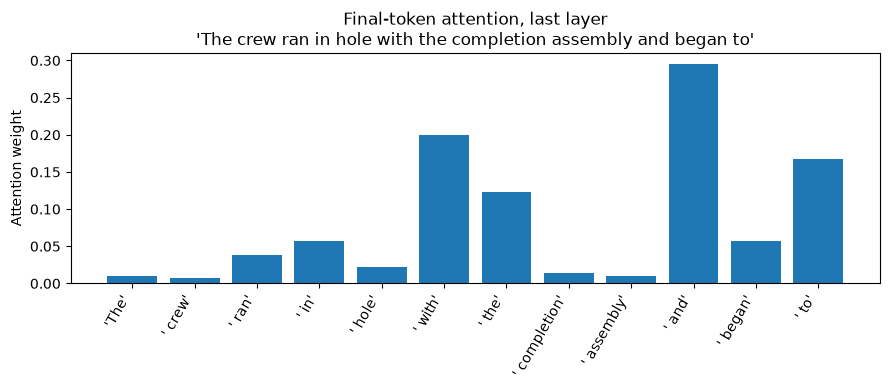

In [14]:
user_word = " tubing"                                                        # <-- change this line
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line

print(f"Nearest neighbors of {user_word!r}:")
display(nearest_neighbors(user_word))

user_encoded = tokenizer(user_prompt, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    user_outputs = model(**user_encoded, output_attentions=True)

user_last_layer_attention = user_outputs.attentions[-1][0].float().mean(dim=0)[-1]
user_labels = [repr(tokenizer.decode([tid])) for tid in user_encoded["input_ids"][0]]

plot_attention(user_last_layer_attention, user_labels, f"Final-token attention, last layer\n{user_prompt!r}")


## 13. Optional exercises

1. In Section 12, try `user_word = " reamer"` or another oilfield term of
   your choice. Are its nearest neighbors semantically related, or mostly
   spelling variants like the examples in Section 4?
2. Pick one of the POOH prompts from the main path's notebook 1 (Section 9 there) and run
   it through Section 12 here. Does the final-token attention concentrate
   on the operation-specific words (e.g. "TCP", "cleanout", "fishing")?
3. In Section 8, try a much shorter prompt (e.g. just "The crew pulled out
   of hole"). Does the early-vs-late-layer attention comparison look
   different with fewer tokens to attend over?
4. Modify Section 6 to print attention weights for one individual head
   (e.g. `outputs.attentions[-1][0][0]`) instead of the head-average. How
   different is one head's pattern from the averaged one?
5. Re-read Section 10. In your own words, write one sentence describing
   what a high attention weight *does* tell you, and one sentence
   describing what it does *not* tell you.


## 14. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [15]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Attention impl:       {model.config._attn_implementation}")
print(f"Layers / heads:       {NUM_LAYERS} / {NUM_HEADS}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float32
Attention impl:       eager
Layers / heads:       28 / 12
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Why `eager` + `float32`, restated.** Two findings from building this
notebook, both directly reproducible by re-running the cells above:

1. With the default attention implementation (`sdpa`), calling the model
   with `output_attentions=True` does not raise an error — it silently
   returns an empty tuple. Real attention weights require
   `attn_implementation="eager"` at load time.
2. With `attn_implementation="eager"` and `dtype=torch.float16` on this
   machine's MPS backend, the resulting attention weights were `NaN`.
   Loading in `float32` instead produced numerically valid attention
   weights (verified: they sum to 1, as shown in Section 6) on MPS, CPU,
   and CUDA.

**Performance note.** Eager attention materializes full attention matrices
and does not benefit from fused-kernel optimizations, so it is slower than
the `sdpa` default used in the main path's notebooks 1–2. For the short prompts used here,
this is not noticeable on a modern laptop.
